# 机器学习实验一：bank 数据任务代码框架

本 Notebook 供实验一使用，建议按顺序完成：

1. 读取 `bank_train.csv` 和 `bank_test.csv`
2. 做基础数据检查与预处理
3. 完成任务一：使用 `sklearn` 构建决策树
4. 完成任务二：手写 ID3
5. 完成选做题（可选）
6. 在实验报告中整理结果与分析



## 0. 导入库


In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

LABEL_COL = "approve"

## 1. 读取数据


In [2]:
train_path = Path("bank_train.csv")
test_path = Path("bank_test.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("请确认当前文件夹中存在 bank_train.csv 和 bank_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("训练集大小：", train_df.shape)
print("测试集大小：", test_df.shape)
train_df.head()


训练集大小： (800, 9)
测试集大小： (200, 9)


,nameid,profession,education,house_loan,car_loan,married,child,revenue,approve
0,1,5,1,0,0,1,1,8204,1
1,2,3,1,1,1,0,0,5674,0
2,3,2,3,1,0,1,0,10634,1
3,4,2,2,0,0,0,0,43551,1
4,5,4,2,0,1,0,1,14065,0


## 2. 数据检查与基础预处理

这一步建议完成：

- 查看字段名是否正确
- 检查是否有缺失值
- 查看标签 `approve` 的分布
- 删除编号列 `nameid`


In [3]:
print("训练集字段：", train_df.columns.tolist())
print("测试集字段：", test_df.columns.tolist())

print("\n训练集缺失值统计：")
print(train_df.isnull().sum())

print("\n测试集缺失值统计：")
print(test_df.isnull().sum())

print("\n训练集标签分布：")
print(train_df["approve"].value_counts())

# 删除不参与建模的编号列
train_base = train_df.drop(columns=["nameid"]).copy()
test_base = test_df.drop(columns=["nameid"]).copy()


feature_cols = [c for c in train_base.columns if c != LABEL_COL]

print("\n特征列：", feature_cols)


训练集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']
测试集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']

训练集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

测试集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

训练集标签分布：
approve
1    518
0    282
Name: count, dtype: int64

特征列： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']


# 3. 任务一：使用 sklearn 构建决策树

建议流程：

- 构造 `X / y`
- 从训练集中划分训练子集和验证集
- 至少比较 3 组参数
- 用验证集选择较优参数
- 用测试集做最终评估
- 绘制决策树


## 3.1 构造 `X / y`


In [4]:
# 任务一使用原始连续 revenue，直接构造 X/y
X_train_all = train_base.drop(columns=[LABEL_COL]).copy()
y_train_all = train_base[LABEL_COL].copy()

X_test = test_base.drop(columns=[LABEL_COL]).copy()
y_test = test_base[LABEL_COL].copy()

print("X_train_all:", X_train_all.shape)
print("y_train_all:", y_train_all.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_all: (800, 7)
y_train_all: (800,)
X_test: (200, 7)
y_test: (200,)


## 3.2 划分训练集 / 验证集


In [5]:
# 从训练集中划分验证集（80% 训练子集 + 20% 验证集）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all,
)

print("训练子集:", X_train.shape)
print("验证集:", X_val.shape)

训练子集: (640, 7)
验证集: (160, 7)


## 3.3 参数设置与训练


In [6]:
# 至少比较 3 组参数
param_list = [
    {"name": "A_gini_d3", "criterion": "gini", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"name": "B_entropy_d4", "criterion": "entropy", "max_depth": 4, "min_samples_split": 2, "min_samples_leaf": 1},
    {"name": "C_entropy_d6_leaf3", "criterion": "entropy", "max_depth": 6, "min_samples_split": 4, "min_samples_leaf": 3},
]

results = []

for params in param_list:
    clf = DecisionTreeClassifier(
        criterion=params["criterion"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42,
    )

    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    results.append({
        "name": params["name"],
        "criterion": params["criterion"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred, zero_division=0),
        "f1": f1_score(y_val, y_val_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print("验证集对比结果（按F1降序）：")
results_df

验证集对比结果（按F1降序）：


,name,criterion,max_depth,min_samples_split,min_samples_leaf,accuracy,precision,recall,f1
0,B_entropy_d4,entropy,4,2,1,0.83125,0.808000,0.971154,0.882096
1,A_gini_d3,gini,3,2,1,0.80625,0.770370,1.000000,0.870293
2,C_entropy_d6_leaf3,entropy,6,4,3,0.76875,0.791304,0.875000,0.831050


## 3.4 选择参数并在测试集上评估


In [7]:
# 根据验证集结果选择较优参数
best_row = results_df.iloc[0]
best_params = {
    "criterion": best_row["criterion"],
    "max_depth": int(best_row["max_depth"]),
    "min_samples_split": int(best_row["min_samples_split"]),
    "min_samples_leaf": int(best_row["min_samples_leaf"]),
}
print("最佳参数:", best_params)

# 用全部训练集（原训练集800条）重新训练最终模型
final_clf = DecisionTreeClassifier(
    criterion=best_params["criterion"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42,
)
final_clf.fit(X_train_all, y_train_all)

# 测试集预测
y_test_pred = final_clf.predict(X_test)

# 测试集指标
print("测试集结果：")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")

最佳参数: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1}
测试集结果：
Accuracy : 0.9900
Precision: 1.0000
Recall   : 0.9880
F1-score : 0.9939


## 3.5 混淆矩阵与决策树可视化


Confusion Matrix:
 [[ 34   0]
 [  2 164]]


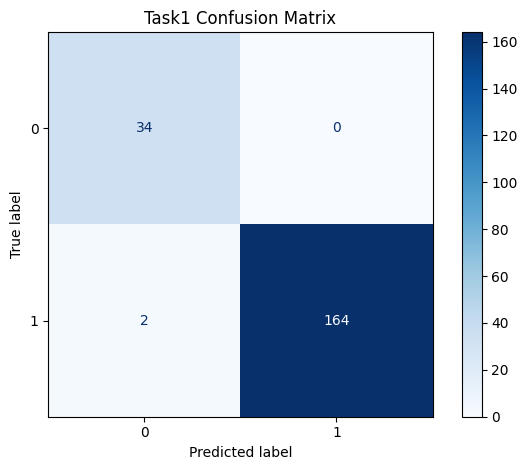

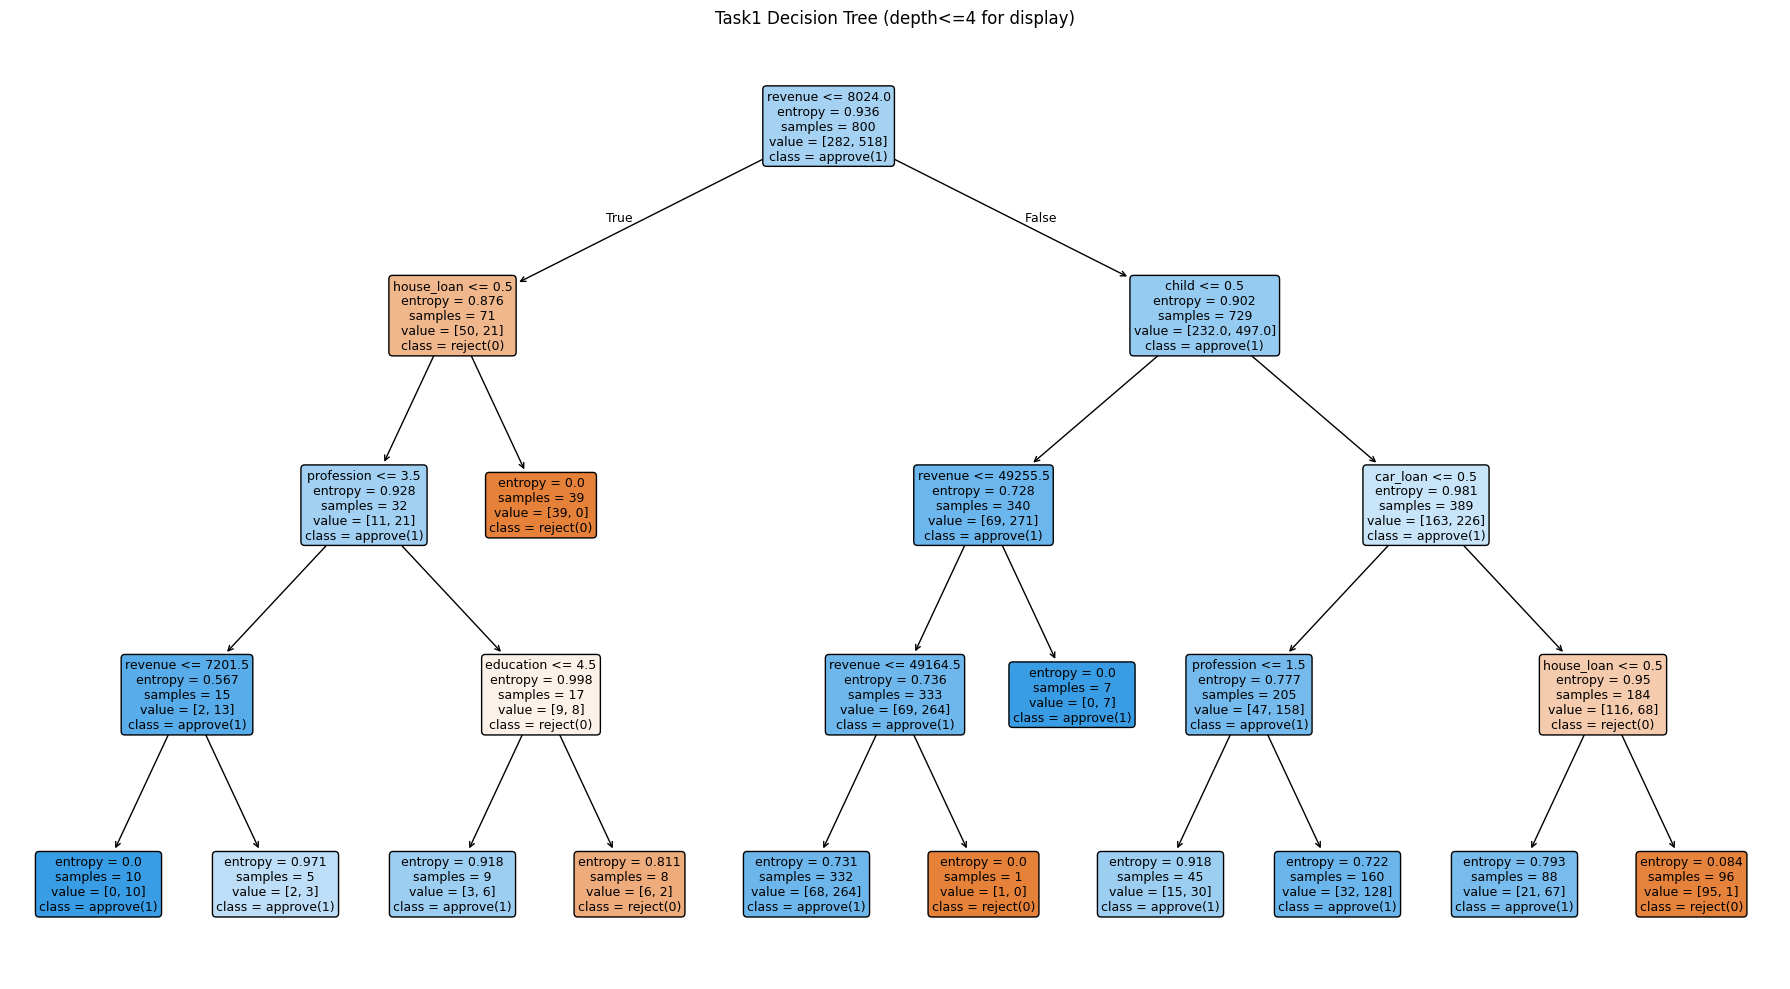

In [8]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Task1 Confusion Matrix")
plt.tight_layout()
plt.savefig("task1_confusion_matrix.png", dpi=200)
plt.show()

# 决策树可视化
plt.figure(figsize=(18, 10))
plot_tree(
    final_clf,
    feature_names=list(X_train_all.columns),
    class_names=["reject(0)", "approve(1)"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9,
)
plt.title("Task1 Decision Tree (depth<=4 for display)")
plt.tight_layout()
plt.savefig("task1_tree.png", dpi=200)
plt.show()

# 4. 任务二：手写 ID3

任务二统一采用：

- 离散特征、多叉树版 ID3
- `revenue` 需要先离散化
- 预测时要处理未见过属性值（fallback）


## 4.1 `revenue` 离散化


In [9]:
# 建议：给任务二单独准备一份数据，避免和任务一互相影响
train_id3 = train_base.copy()
test_id3 = test_base.copy()

# 对 revenue 做离散化（多段分箱）
bins = [-np.inf, 10000, 20000, 30000, 40000, np.inf]
labels = ["very_low", "low", "mid", "high", "very_high"]
train_id3["revenue"] = pd.cut(
    train_id3["revenue"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
).astype(str)
test_id3["revenue"] = pd.cut(
    test_id3["revenue"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
).astype(str)

print(train_id3[["revenue", LABEL_COL]].head())

     revenue  approve
0   very_low        1
1   very_low        0
2        low        1
3  very_high        1
4        low        0


## 4.2 核心函数骨架


In [10]:
def calc_entropy(data, label=LABEL_COL):
    counts = data[label].value_counts()
    probs = counts / len(data)
    return -sum(p * math.log2(p) for p in probs if p > 0)


def calc_info_gain(data, feature, label=LABEL_COL):
    base_entropy = calc_entropy(data, label)
    weighted_entropy = 0.0

    for _, subset in data.groupby(feature):
        weighted_entropy += (len(subset) / len(data)) * calc_entropy(subset, label)

    return base_entropy - weighted_entropy


def majority_class(data, label=LABEL_COL):
    return data[label].value_counts().idxmax()


def build_tree(data, features, label=LABEL_COL, max_depth=None, current_depth=0):
    # 终止条件1：样本全属于同一类别
    if data[label].nunique() == 1:
        pure_label = data[label].iloc[0]
        return {"type": "leaf", "label": pure_label}

    # 终止条件2：没有可分特征
    if len(features) == 0:
        return {"type": "leaf", "label": majority_class(data, label)}

    # 终止条件3：预剪枝（可选）
    if max_depth is not None and current_depth >= max_depth:
        return {"type": "leaf", "label": majority_class(data, label)}

    gains = {feat: calc_info_gain(data, feat, label) for feat in features}
    best_feature = max(gains.keys(), key=lambda k: gains[k])

    node = {
        "type": "node",
        "feature": best_feature,
        "majority": majority_class(data, label),
        "children": {},
    }

    remaining_features = [f for f in features if f != best_feature]
    for value, subset in data.groupby(best_feature):
        if subset.empty:
            node["children"][value] = {"type": "leaf", "label": node["majority"]}
        else:
            node["children"][value] = build_tree(
                subset,
                remaining_features,
                label=label,
                max_depth=max_depth,
                current_depth=current_depth + 1,
            )

    return node


def predict_one(tree, sample):
    cur = tree
    while cur["type"] != "leaf":
        feat = cur["feature"]
        value = sample[feat]
        if value not in cur["children"]:
            return cur["majority"]
        cur = cur["children"][value]
    return cur["label"]


def predict(tree, data):
    return data.apply(lambda row: predict_one(tree, row), axis=1)

## 4.3 模型训练与测试集评估


In [11]:
# 任务二训练与评估
id3_features = [c for c in train_id3.columns if c != LABEL_COL]

tree = build_tree(train_id3, id3_features, label=LABEL_COL)

y_true = test_id3[LABEL_COL]
y_pred = predict(tree, test_id3[id3_features])

# 手写 TP/TN/FP/FN
TP = int(((y_true == 1) & (y_pred == 1)).sum())
TN = int(((y_true == 0) & (y_pred == 0)).sum())
FP = int(((y_true == 0) & (y_pred == 1)).sum())
FN = int(((y_true == 1) & (y_pred == 0)).sum())

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"ID3 Accuracy : {accuracy:.4f}")
print(f"ID3 Precision: {precision:.4f}")
print(f"ID3 Recall   : {recall:.4f}")
print(f"ID3 F1-score : {f1:.4f}")

# 与任务一 sklearn 决策树结果对比
sk_acc = accuracy_score(y_test, y_test_pred)
sk_pre = precision_score(y_test, y_test_pred, zero_division=0)
sk_rec = recall_score(y_test, y_test_pred, zero_division=0)
sk_f1 = f1_score(y_test, y_test_pred, zero_division=0)

compare_df = pd.DataFrame([
    {"model": "sklearn_tree", "accuracy": sk_acc, "precision": sk_pre, "recall": sk_rec, "f1": sk_f1},
    {"model": "manual_id3", "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1},
])

print("\nTask1 vs Task2 指标对比：")
compare_df

TP=128, TN=33, FP=1, FN=38
ID3 Accuracy : 0.8050
ID3 Precision: 0.9922
ID3 Recall   : 0.7711
ID3 F1-score : 0.8678

Task1 vs Task2 指标对比：


,model,accuracy,precision,recall,f1
0,sklearn_tree,0.990,1.000000,0.987952,0.993939
1,manual_id3,0.805,0.992248,0.771084,0.867797
